In [1]:
import sys
sys.path.insert(0, '../')
from plotting import *
setup_plotting()

## Acceleration Methods

[Dempster et al.](https://scholar.google.com.au/scholar?cluster=7728340850644612874&hl=en&as_sdt=0,5) showed that the convergence rate for the EM algorithm is linear, which can be painfully slow for some problems. Therefore, a cottage industry has developed around the notion of speeding up the convergence of the algorithm. Two approaches that we describe here are one proposed by [Tom Louis](https://scholar.google.com.au/scholar?cluster=16739076398862183494&hl=en&as_sdt=0,5) based on the Aitken acceleration technique and the SQUAREM approach of [Varadhan and Roland](https://scholar.google.com.au/scholar?cluster=7793127575328145646&hl=en&as_sdt=0,5).

### Louis's Acceleration

If we let $M(\theta)$ be the map representing a single iteration of the EM algorithm, so that $\theta_{n+1} = M(\theta_n)$. Then under standard regularity conditions, we can approximate $M$ near the optimum value $\theta^\star$ with

$$\theta_{n+1} = M(\theta_n) \approx \theta_n + J(\theta_{n-1})(\theta_n - \theta_{n-1})$$

where [Dempster et al. 1977](https://scholar.google.com.au/scholar?cluster=7728340850644612874&hl=en&as_sdt=0,5) showed that $J$ is

$$J(\theta) = I_{Z|Y}(\theta)\,I_{Z,Y}(\theta)^{-1},$$

which can be interpreted as characterizing the proportion of missing data. (Dempster et al. also showed that the rate of convergence of the EM algorithm is determined by the modulus of the largest eigenvalue of $J(\theta^\star)$.)

Furthermore, for large $j$ and $n$, we have

$$\theta_{n+j+1} - \theta_{n+j} \approx J^{(n)}(\theta^\star)(\theta_{j+1} - \theta_j)$$

where $\theta^\star$ is the MLE, and $J^{(n)}(\theta^\star)$ is $J$ multiplied by itself $n$ times. Then if $\theta^\star$ is the limit of the sequence $\{\theta_n\}$, we can write (trivially) for any $j$

$$\theta^\star = \theta_j + \sum_{k=1}^\infty(\theta_{k+j} - \theta_{k+j-1})$$

We can then approximate this with

$$\theta^\star \approx \theta_j + \left(\sum_{k=0}^\infty J^{(k)}(\theta^\star)\right)(\theta_{j+1} - \theta_j) = \theta_j + (I - J(\theta^\star))^{-1}(\theta_{j+1} - \theta_j)$$

The last equivalence is possible because the eigenvalues of $J$ are all less than one in absolute value.

Given this relation, the acceleration method proposed by Louis works as follows. Given $\theta_n$, the current estimate of $\theta$,

1. Compute $\theta_{n+1}$ using the standard EM algorithm
2. Compute 

$$
(I-\hat{J})^{-1} = I_{Y,Z}(\theta_n)\,I_Y(\theta_n)^{-1}
$$


3. Let 

$$
\theta^\star = \theta_n + (I-\hat{J})^{-1}(\theta_{n+1} - \theta_n)
$$

.
4. Set $\theta_{n+1} = \theta^\star$.

The cost of using Louis's technique is minimal if the dimension of $\theta$ is small. Ultimately, it comes down to the cost of inverting $I_Y(\theta_n)$ relative to running a single iteration of the EM algorithm. Further, it's worth emphasizing that the convergence of the approach is only guaranteed for values of $\theta$ in a neighborhood of the optimum $\theta^\star$, but the size and nature of that neighborhood is typically unknown in applications.

Looking at the algorithm described above, we can gather some basic heuristics of how it works. When the information in the observed data is high relative to the complete data, then the value of $(I-\hat{J})^{-1}$ will be close to 1 and the sequence of iterates generated by the algorithm will be very similar to the usual EM sequence. However, if the proportion of missing data is high, then $(I-\hat{J})^{-1}$ will be much greater than 1 and the modifications that the algorithm makes to the usual EM sequence will be large.

#### Example: Normal Mixture Model

Recall that the data are generated as follows.

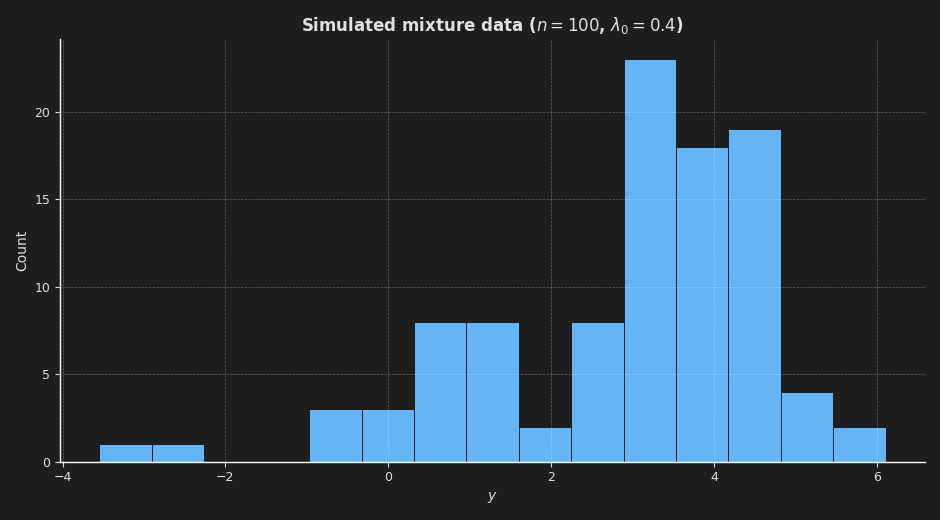

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import optimize, stats
mu1 = 1
s1 = 2
mu2 = 4
s2 = 1
lambda0 = 0.4
n = 100
rng = np.random.default_rng(20170912)
z = rng.binomial(1, lambda0, size=n)
y = rng.normal(mu1 * z + mu2 * (1-z), s1 * z + (1-z) * s2)
fig, ax = plt.subplots()
ax.hist(y, bins=15, color=C['blue'], edgecolor='black', linewidth=0.5)
ax.set_xlabel('$y$')
ax.set_ylabel('Count')
ax.set_title('Simulated mixture data ($n=100$, $\\lambda_0=0.4$)')
plt.tight_layout()


In [3]:
def make_pi(lam, y, mu1, mu2, s1, s2):
    """Posterior probability that observation came from component 1 (E-step)"""
    return lam * stats.norm.pdf(y, mu1, s1) / (lam * stats.norm.pdf(y, mu1, s1) + 
                                                (1 - lam) * stats.norm.pdf(y, mu2, s2))

def M(lambda0):
    """EM update step (M-step)"""
    pi_est = make_pi(lambda0, y, mu1, mu2, s1, s2)
    return np.mean(pi_est)

In [4]:
def f(x, lam, mu1, mu2, s1, s2):
    """PDF of mixture of two Gaussians"""
    return lam * stats.norm.pdf(x, mu1, s1) + (1 - lam) * stats.norm.pdf(x, mu2, s2)

def loglike(lam):
    """Log-likelihood of lambda given observed data y"""
    return np.sum(np.log(f(y, lam, mu1, mu2, s1, s2)))

If we assume $\mu_1$, $\mu_2$, $\sigma_1$ and $\sigma_2$ are known, then we can visualize the observed data log-likelihood as a function of $\lambda$.

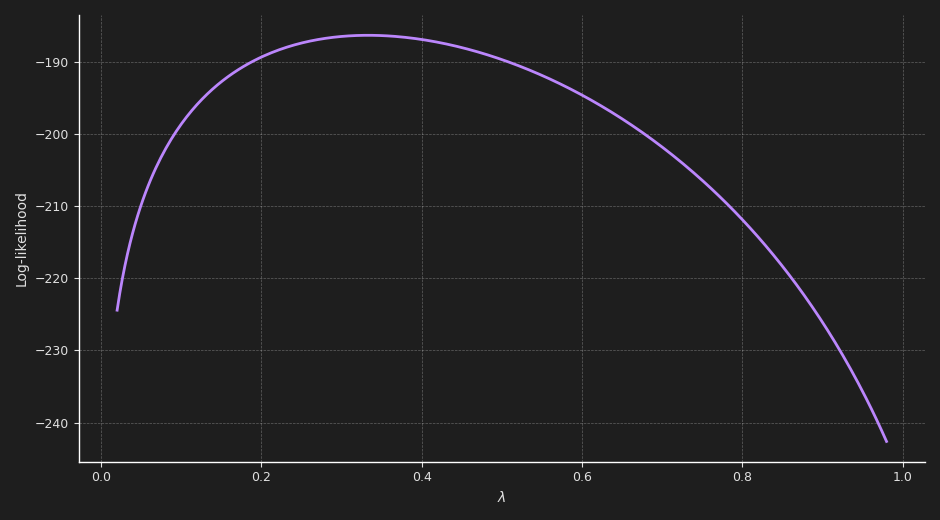

In [5]:
lam_grid = np.linspace(0.02, 0.98, 300)
ll_vals = np.array([loglike(l) for l in lam_grid])
fig, ax = plt.subplots()
ax.plot(lam_grid, ll_vals, lw=2)
ax.set_xlabel('$\\lambda$')
ax.set_ylabel('Log-likelihood')
plt.tight_layout()


Because the observed log-likelihood is relatively simple in this case, we can maximize it directly and obtain the true maximum likelihood estimate.

In [6]:
op = optimize.minimize_scalar(lambda x: -loglike(x), bounds=(0.01, 0.95), method="bounded")
op.x

np.float64(0.33313681159822994)

Taking a starting value of $\lambda = 0.1$, we can see the speed at which the original EM algorithm and the accelerated versions converge toward the MLE.

In [7]:
def Iy(lambda0):
    """Observed data information matrix (Fisher information of log-likelihood)"""
    eps = 1e-8
    l1 = np.sum(np.log(lambda0 * stats.norm.pdf(y, mu1, s1) + (1-lambda0) * stats.norm.pdf(y, mu2, s2)))
    l2 = np.sum(np.log((lambda0+eps) * stats.norm.pdf(y, mu1, s1) + (1-lambda0-eps) * stats.norm.pdf(y, mu2, s2)))
    l3 = np.sum(np.log((lambda0-eps) * stats.norm.pdf(y, mu1, s1) + (1-lambda0+eps) * stats.norm.pdf(y, mu2, s2)))
    # Hessian via finite differences
    return (l2 - 2*l1 + l3) / (eps**2)

def Iyz(lambda0):
    """Complete data information matrix"""
    pihat = make_pi(lambda0, y, mu1, mu2, s1, s2)
    eps = 1e-8
    # For log(lambda) and log(1-lambda) terms
    l1 = np.sum(pihat * np.log(lambda0) + (1-pihat) * np.log(1-lambda0))
    l2 = np.sum(pihat * np.log(lambda0+eps) + (1-pihat) * np.log(1-lambda0-eps))
    l3 = np.sum(pihat * np.log(lambda0-eps) + (1-pihat) * np.log(1-lambda0+eps))
    # Hessian via finite differences
    return (l2 - 2*l1 + l3) / (eps**2)

def Mstar(lambda0):
    """Accelerated EM update using the squarem approach"""
    lambda1 = M(lambda0)
    iy = Iy(lambda0)
    iyz = Iyz(lambda0)
    # Avoid division by zero
    if abs(iy) < 1e-10:
        return lambda1
    return lambda0 + (iyz / iy) * (lambda1 - lambda0)

In [8]:
lambda0 = 0.1
lambda0star = 0.1
iter = 6
EM = np.zeros(iter)
Accel = np.zeros(iter)
for i in range(iter):
    pihat = make_pi(lambda0, y, mu1, mu2, s1, s2)
    lambda1 = M(lambda0)
    lambda1star = Mstar(lambda0star)
    EM[i] = lambda1
    Accel[i] = lambda1star
    lambda0 = lambda1
    lambda0star = lambda1star

# Create results as a pandas DataFrame
import pandas as pd
results = pd.DataFrame({
    'EM': EM,
    'Accel': Accel,
    'errorEM': np.abs(EM - op.x),
    'errorAccel': np.abs(Accel - op.x)
})
results

,EM,Accel,errorEM,errorAccel
0,0.238855,0.363824,0.094282,0.030687
1,0.297432,0.360706,0.035705,0.027569
2,0.319506,0.369116,0.013630,0.035980
3,0.327902,0.377329,0.005235,0.044193
4,0.331120,0.350493,0.002016,0.017356
5,0.332359,0.371728,0.000778,0.038591


After six iterations, we have the following.